In [5]:
import pandas as pd
import matplotlib.pyplot as plt

matches = pd.read_csv("data/gold_match.csv")

                     tickets_scanned  last_result_numeric
tickets_scanned             1.000000            -0.170157
last_result_numeric        -0.170157             1.000000


C:\Users\User\AppData\Local\Temp\ipykernel_4776\2248655745.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["last_result_numeric"] = df["last_result_vs_opponent"].apply(parse_result)


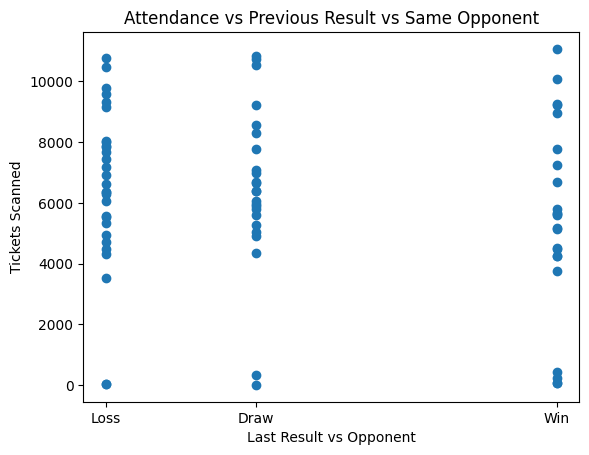

<Figure size 640x480 with 0 Axes>

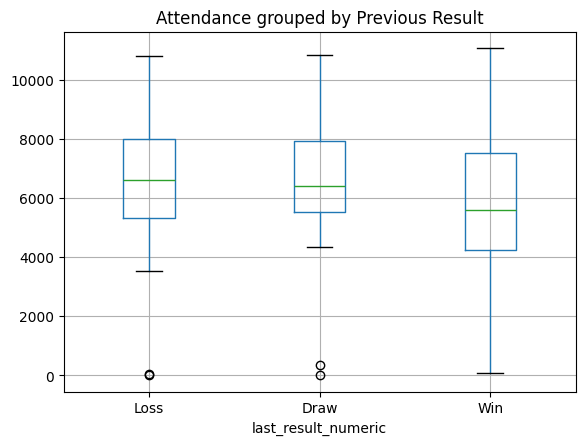

last_result_numeric
0    6559.689655
1    6475.833333
3    5448.217391
Name: tickets_scanned, dtype: float64


In [6]:
import pandas as pd

df = matches.dropna(subset=["tickets_scanned", "last_result_vs_opponent"])

def parse_result(value: str) -> int:
    if value.startswith("W"):
        return 3
    elif value.startswith("D"):
        return 1
    elif value.startswith("L"):
        return 0
    return None

df["last_result_numeric"] = df["last_result_vs_opponent"].apply(parse_result)

df = df.dropna(subset=["last_result_numeric"])

corr = df[["tickets_scanned", "last_result_numeric"]].corr()
print(corr)

plt.figure()
plt.scatter(df["last_result_numeric"], df["tickets_scanned"])
plt.xticks([0, 1, 3], ["Loss", "Draw", "Win"])
plt.xlabel("Last Result vs Opponent")
plt.ylabel("Tickets Scanned")
plt.title("Attendance vs Previous Result vs Same Opponent")
plt.show()

plt.figure()
df.boxplot(column="tickets_scanned", by="last_result_numeric")
plt.title("Attendance grouped by Previous Result")
plt.suptitle("")
plt.xticks([1, 2, 3], ["Loss", "Draw", "Win"])
plt.show()

grouped = df.groupby("last_result_numeric")["tickets_scanned"].mean()
print(grouped)

##### An example of merging tables

R²:           0.029
Slope:        -383.6205
P-value:      0.1417
Std Error:    258.2599
95% CI:       [-889.8099, 122.5689]


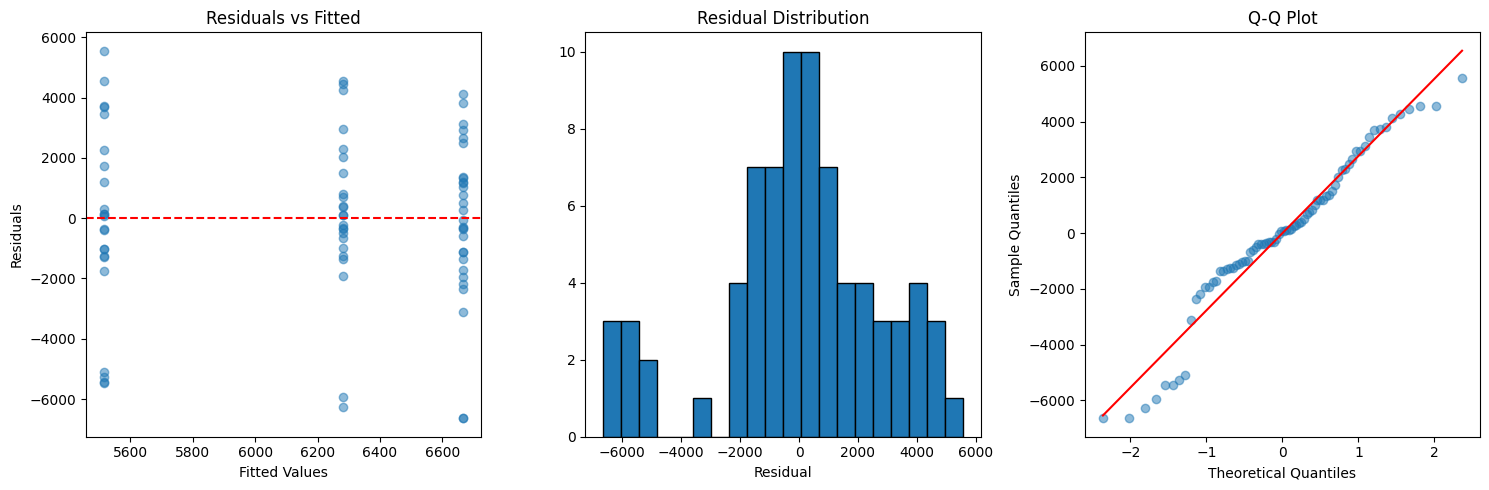


ANOVA F-statistic: 1.1749
ANOVA P-value:     0.3146


C:\Users\User\AppData\Local\Temp\ipykernel_4776\3190836705.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([loss, draw, win], labels=["Loss", "Draw", "Win"])


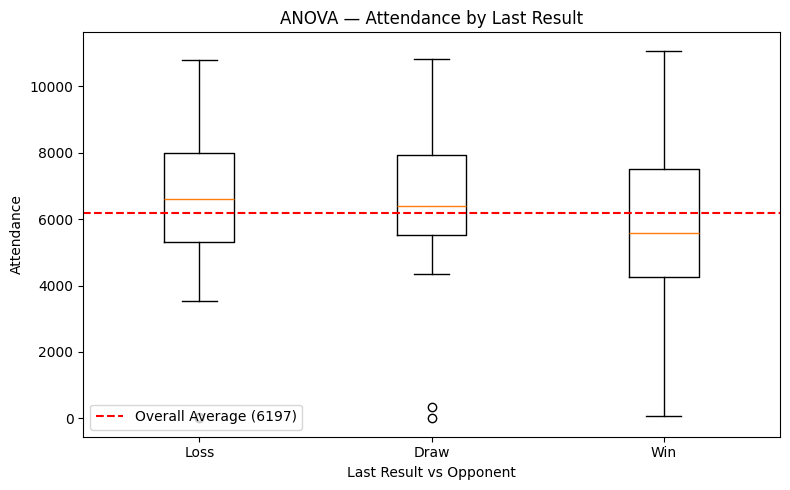

In [47]:
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.linear_model import LinearRegression

X = df[["last_result_numeric"]]
y = df["tickets_scanned"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
residuals = y - y_pred

# ── P-value + Confidence Intervals (via scipy) ──
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df["last_result_numeric"], df["tickets_scanned"]
)
ci_lower = slope - 1.96 * std_err
ci_upper = slope + 1.96 * std_err

print(f"R²:           {r_value**2:.3f}")
print(f"Slope:        {slope:.4f}")
print(f"P-value:      {p_value:.4f}")
print(f"Std Error:    {std_err:.4f}")
print(f"95% CI:       [{ci_lower:.4f}, {ci_upper:.4f}]")

# ── Residual plots ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Residuals vs fitted
axes[0].scatter(y_pred, residuals, alpha=0.5)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

# Histogram of residuals
axes[1].hist(residuals, bins=20, edgecolor="black")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

# Q-Q plot
(osm, osr), (slope_qq, intercept_qq, r_qq) = stats.probplot(residuals)
axes[2].scatter(osm, osr, alpha=0.5)
axes[2].plot(osm, slope_qq * osm + intercept_qq, color="red")
axes[2].set_xlabel("Theoretical Quantiles")
axes[2].set_ylabel("Sample Quantiles")
axes[2].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()

# ── ANOVA ──
loss = df[df["last_result_numeric"] == 0]["tickets_scanned"]
draw = df[df["last_result_numeric"] == 1]["tickets_scanned"]
win  = df[df["last_result_numeric"] == 3]["tickets_scanned"]

f_stat, p_anova = stats.f_oneway(loss, draw, win)
print(f"\nANOVA F-statistic: {f_stat:.4f}")
print(f"ANOVA P-value:     {p_anova:.4f}")

# Boxplot
plt.figure(figsize=(8, 5))
plt.boxplot([loss, draw, win], labels=["Loss", "Draw", "Win"])
plt.axhline(y.mean(), color="red", linestyle="--", label=f"Overall Average ({y.mean():.0f})")
plt.xlabel("Last Result vs Opponent")
plt.ylabel("Attendance")
plt.title("ANOVA — Attendance by Last Result")
plt.legend()
plt.tight_layout()
plt.show()

away_team
Anderlecht              9828.250000
Club Brugge             9115.750000
Antwerp                 8276.333333
Standard Liège          7500.166667
Mechelen                7380.833333
Union Saint-Gilloise    6936.250000
Genk                    6756.750000
Gent                    6724.600000
Westerlo                6666.200000
Beerschot               6655.000000
Sint-Truiden            6376.600000
Kortrijk                6323.666667
Zulte Waregem           6139.500000
Cercle Brugge           6024.750000
Eupen                   5700.000000
Sporting Charleroi      5587.200000
Seraing                 5285.000000
Dender                  5057.000000
KV Oostende             4489.000000
Name: tickets_scanned, dtype: float64


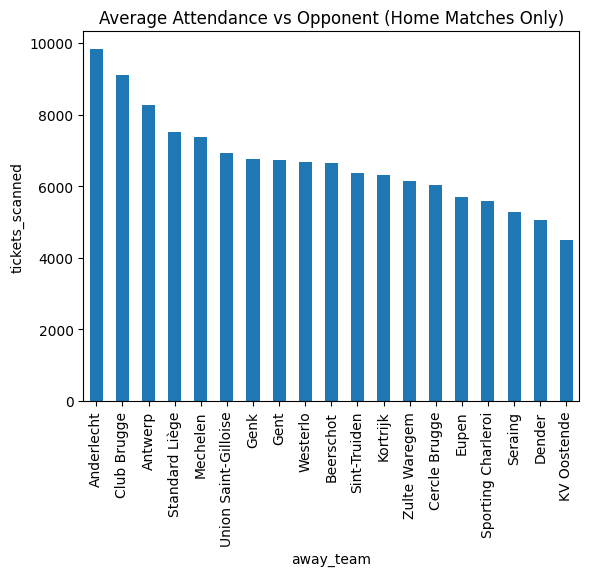

away_team
Anderlecht              4
Antwerp                 3
Beerschot               1
Cercle Brugge           4
Club Brugge             4
Dender                  3
Eupen                   2
Genk                    4
Gent                    5
KV Oostende             1
Kortrijk                3
Mechelen                6
Seraing                 1
Sint-Truiden            5
Sporting Charleroi      5
Standard Liège          6
Union Saint-Gilloise    4
Westerlo                5
Zulte Waregem           2
Name: tickets_scanned, dtype: int64


In [44]:
df_home = df[df["is_home_match"] == True]
df_home = df_home.dropna(subset=["tickets_scanned", "away_team"])

attendance_by_team = df_home.groupby("away_team")["tickets_scanned"].mean().sort_values(ascending=False)
print(attendance_by_team)

plt.figure()
attendance_by_team.plot(kind="bar")
plt.ylabel("tickets_scanned")
plt.title("Average Attendance vs Opponent (Home Matches Only)")
plt.xticks(rotation=90)
plt.show()

games_per_team = df_home.groupby("away_team")["tickets_scanned"].count()
print(games_per_team)

R² Score: 0.374
                    team  effect_on_attendance  predicted_attendance
0             Anderlecht           3153.363158          10061.966099
4            Club Brugge           2440.863158           9349.466099
1                Antwerp           1601.446491           8510.049432
15        Standard Liège            825.279825           7733.882766
11              Mechelen            705.946491           7614.549432
16  Union Saint-Gilloise            261.363158           7169.966099
7                   Genk             81.863158           6990.466099
8                   Gent             49.713158           6958.316099
17              Westerlo             -8.686842           6899.916099
2              Beerschot            -19.886842           6888.716099
13          Sint-Truiden           -298.286842           6610.316099
10              Kortrijk           -351.220175           6557.382766
18         Zulte Waregem           -535.386842           6373.216099
3          Cercle 

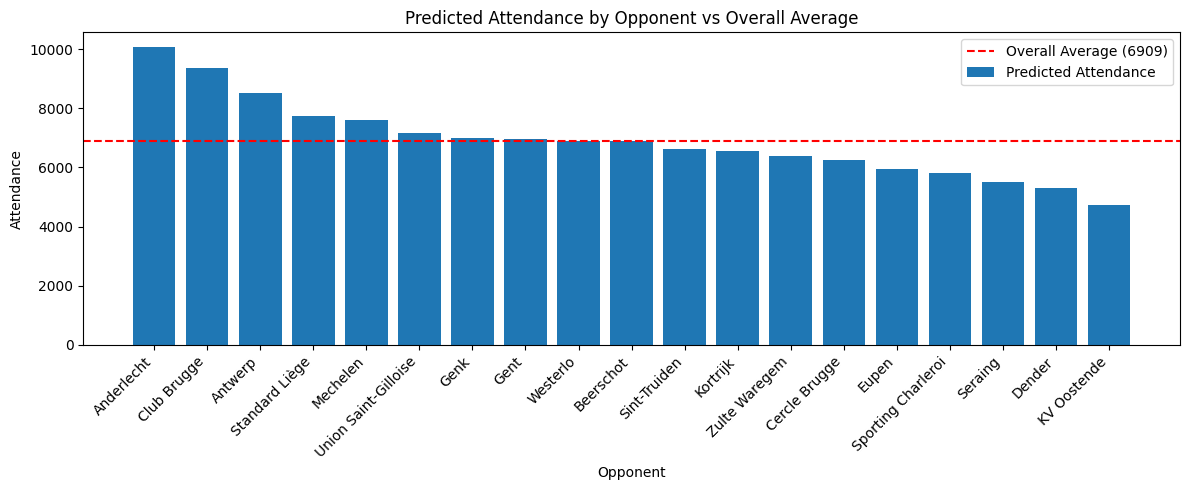

In [28]:
from sklearn.linear_model import LinearRegression

X = pd.get_dummies(df_home["away_team"])
y = df_home["tickets_scanned"]

model = LinearRegression()
model.fit(X, y)

print(f"R² Score: {model.score(X, y):.3f}")

avg_attendance = df_home["tickets_scanned"].mean()

coef_df = pd.DataFrame({
    "team": X.columns,
    "effect_on_attendance": model.coef_
}).sort_values("effect_on_attendance", ascending=False)

coef_df["predicted_attendance"] = avg_attendance + coef_df["effect_on_attendance"]

print(coef_df)

plt.figure(figsize=(12, 5))
plt.bar(coef_df["team"], coef_df["predicted_attendance"], label="Predicted Attendance")
plt.axhline(avg_attendance, color="red", linestyle="--", label=f"Overall Average ({avg_attendance:.0f})")
plt.xlabel("Opponent")
plt.ylabel("Attendance")
plt.title("Predicted Attendance by Opponent vs Overall Average")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

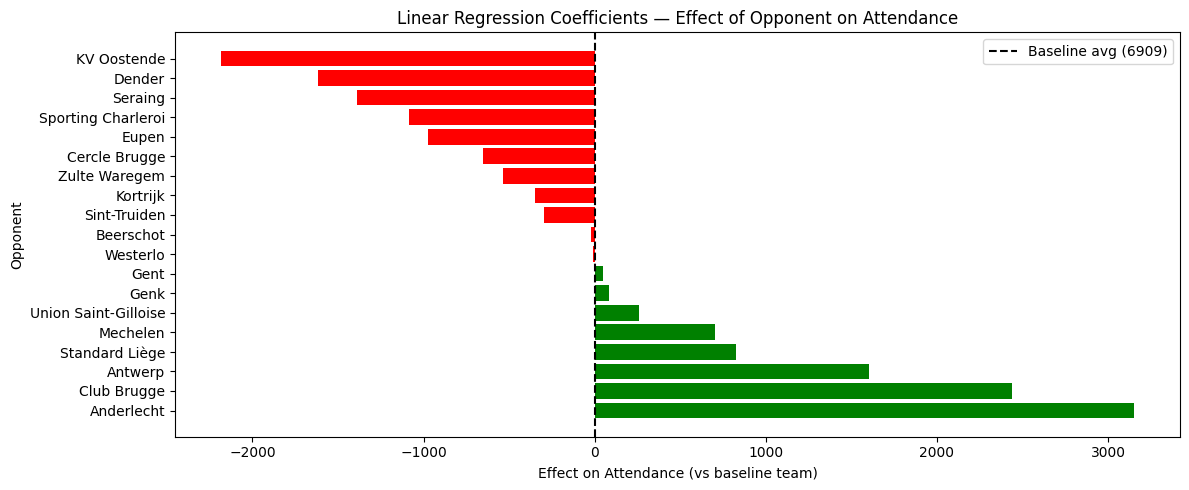

In [29]:
plt.figure(figsize=(12, 5))
colors = ["green" if x > 0 else "red" for x in coef_df["effect_on_attendance"]]
plt.barh(coef_df["team"], coef_df["effect_on_attendance"], color=colors)
plt.axvline(0, color="black", linestyle="--", label=f"Baseline avg ({avg_attendance:.0f})")
plt.xlabel("Effect on Attendance (vs baseline team)")
plt.ylabel("Opponent")
plt.title("Linear Regression Coefficients — Effect of Opponent on Attendance")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_4776\2824751966.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grouped, labels=team_order)


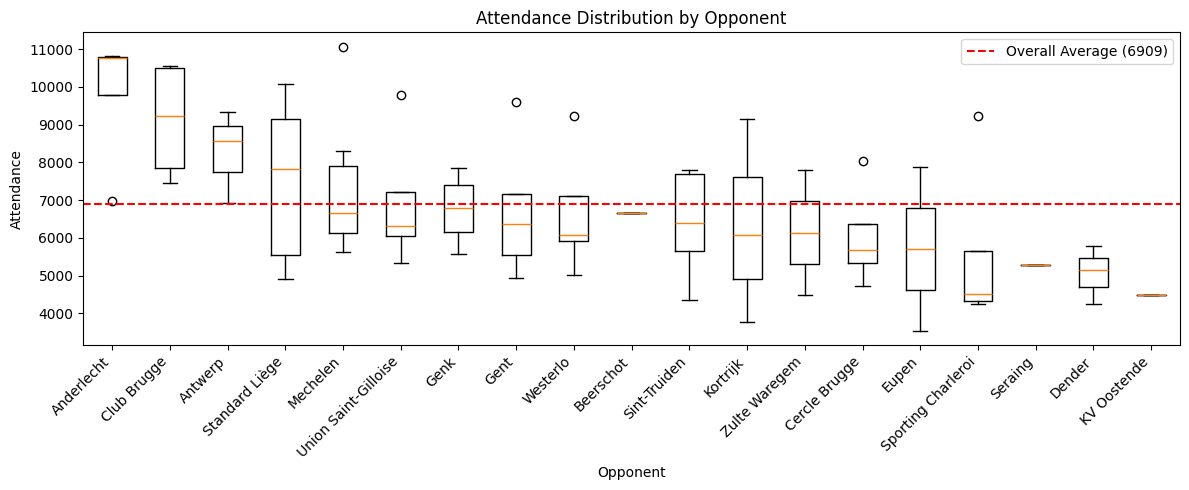

Index(['match_id', 'match_date', 'kickoff_time_local', 'match_date_utc',
       'kickoff_time_utc', 'matchday', 'competition_id', 'competition_name',
       'season', 'season_id', 'stage', 'home_team_id', 'home_team',
       'home_team_code', 'away_team_id', 'away_team', 'away_team_code',
       'venue', 'winner', 'result_home', 'goals_home_ht', 'goals_away_ht',
       'goals_home_ft', 'goals_away_ft', 'is_home_match',
       'last_result_vs_opponent', 'tickets_scanned', 'last_result_numeric'],
      dtype='object')


In [32]:
team_order = coef_df["team"].tolist()
grouped = [df_home[df_home["away_team"] == team]["tickets_scanned"].values for team in team_order]

plt.figure(figsize=(12, 5))
plt.boxplot(grouped, labels=team_order)
plt.axhline(avg_attendance, color="red", linestyle="--", label=f"Overall Average ({avg_attendance:.0f})")
plt.xlabel("Opponent")
plt.ylabel("Attendance")
plt.title("Attendance Distribution by Opponent")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()

plt.show()

print(df.columns)

R²: 0.106
Coefficient: 70.5102


C:\Users\User\AppData\Local\Temp\ipykernel_4776\3117994273.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grouped, labels=matchdays)


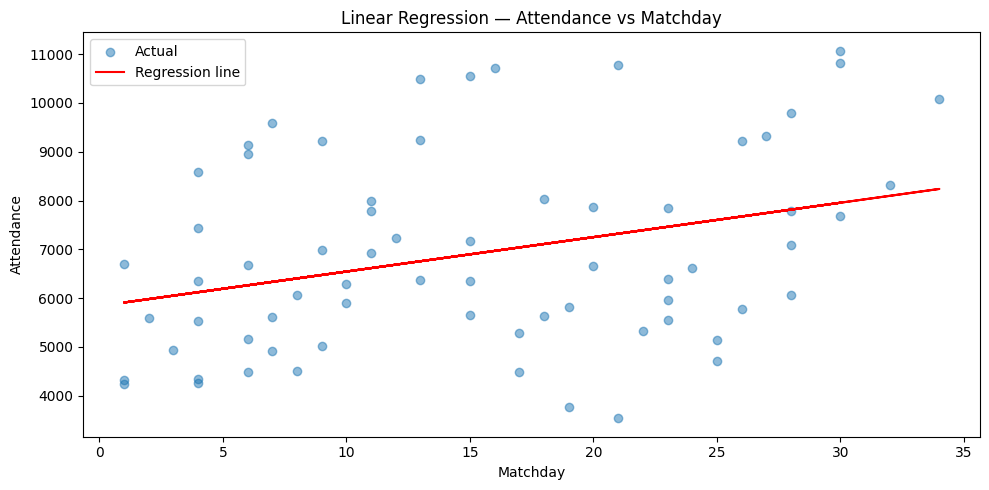

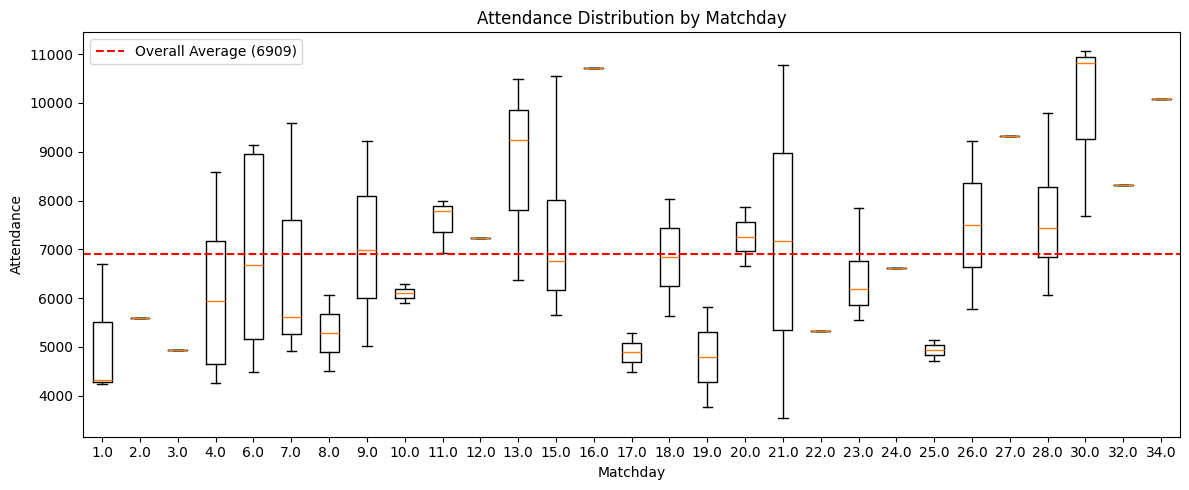

In [42]:
X = df_home[["matchday"]]
y = df_home["tickets_scanned"]

model = LinearRegression()
model.fit(X, y)

print(f"R²: {model.score(X, y):.3f}")
print(f"Coefficient: {model.coef_[0]:.4f}")

plt.figure(figsize=(10, 5))
plt.scatter(df_home["matchday"], y, alpha=0.5, label="Actual")
plt.plot(df_home["matchday"], model.predict(X), color="red", label="Regression line")
plt.xlabel("Matchday")
plt.ylabel("Attendance")
plt.title("Linear Regression — Attendance vs Matchday")
plt.legend()
plt.tight_layout()

plt.figure(figsize=(12, 5))
matchdays = sorted(df_home["matchday"].unique())
grouped = [df_home[df_home["matchday"] == m]["tickets_scanned"].values for m in matchdays]
plt.boxplot(grouped, labels=matchdays)
plt.axhline(y.mean(), color="red", linestyle="--", label=f"Overall Average ({y.mean():.0f})")
plt.xlabel("Matchday")
plt.ylabel("Attendance")
plt.title("Attendance Distribution by Matchday")
plt.legend()
plt.tight_layout()

plt.show()

R²:        0.011
Slope:     -100.7529
P-value:   0.6317
95% CI:    [-506.9517, 305.4460]


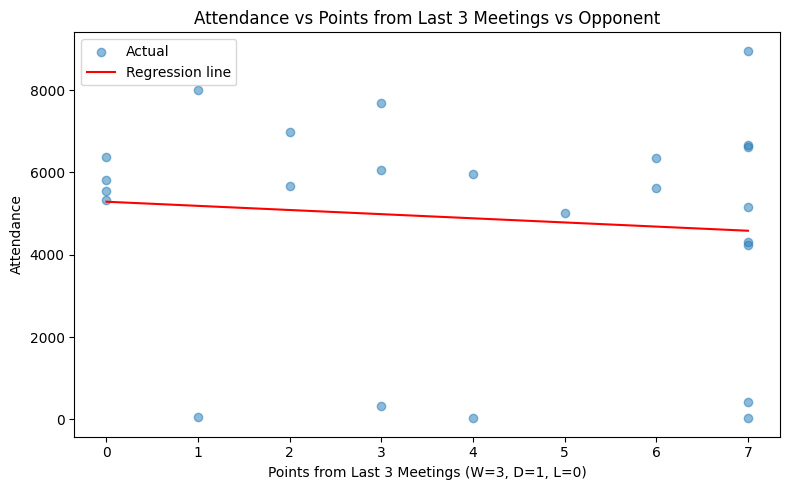

C:\Users\User\AppData\Local\Temp\ipykernel_4776\1061803876.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grouped, labels=[int(p) for p in point_values])


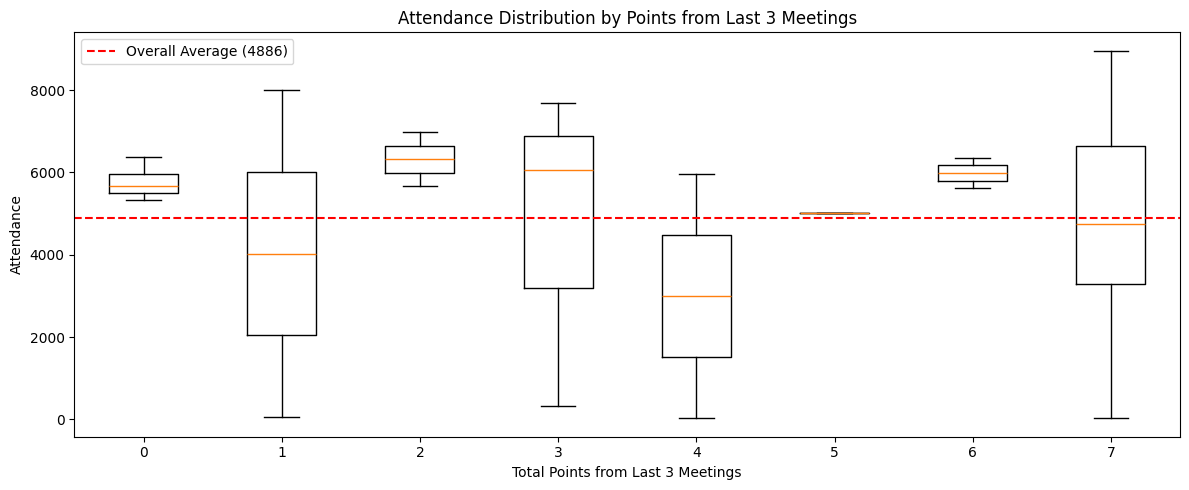

In [49]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# ── Sum of points from last 3 meetings ──
df_lag["points_last_3"] = (
    df_lag["result_minus_1"].fillna(0) +
    df_lag["result_minus_2"].fillna(0) +
    df_lag["result_minus_3"].fillna(0)
)

# ── Regression: points last 3 vs attendance ──
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_lag["points_last_3"], df_lag["tickets_scanned"]
)
ci_lower = slope - 1.96 * std_err
ci_upper = slope + 1.96 * std_err

print(f"R²:        {r_value**2:.3f}")
print(f"Slope:     {slope:.4f}")
print(f"P-value:   {p_value:.4f}")
print(f"95% CI:    [{ci_lower:.4f}, {ci_upper:.4f}]")

# ── Regression plot ──
x = df_lag["points_last_3"]
y = df_lag["tickets_scanned"]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.5, label="Actual")
plt.plot(sorted(x), [intercept + slope * v for v in sorted(x)], color="red", label="Regression line")
plt.xlabel("Points from Last 3 Meetings (W=3, D=1, L=0)")
plt.ylabel("Attendance")
plt.title("Attendance vs Points from Last 3 Meetings vs Opponent")
plt.legend()
plt.tight_layout()
plt.show()

# ── Boxplot per points total ──
plt.figure(figsize=(12, 5))
point_values = sorted(x.unique())
grouped = [df_lag[df_lag["points_last_3"] == p]["tickets_scanned"].values for p in point_values]
plt.boxplot(grouped, labels=[int(p) for p in point_values])
plt.axhline(y.mean(), color="red", linestyle="--", label=f"Overall Average ({y.mean():.0f})")
plt.xlabel("Total Points from Last 3 Meetings")
plt.ylabel("Attendance")
plt.title("Attendance Distribution by Points from Last 3 Meetings")
plt.legend()
plt.tight_layout()
plt.show()